In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
    
sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import precision_mapping as pm

# Loads test suite paths
from precision_mapping.tests.constants_test_suite import *

In [2]:
dtseries_path = TEST_DTSERIES_PATH  # path to dtseries or .txt with lines of dtseries paths
subject_id = TEST_SUBJECT_ID  # name of subject (output directory will use this)
sample_label = TEST_SAMPLE_LABEL # sample label (normally '{subject}_additional_info')
outdir = TEST_DIR_PATH # output directory
censor_file = TEST_DTSERIES_CENSOR_FILE # path to frame censoring .dat file

# pm.precision_mapping(dtseries_path, subject_id, sample_label, outdir,
#                      censor_files=censor_file, device="default", seed=4,
#                      sparsity=0.01, n_infomaps_reps=1, overwrite=True)

In [3]:

dtseries_path = '/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii'
censor_file = None
npz_path = "/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/100610/100610_rfMRI_REST_7T_ALL_vertex_FC.npz"

# Adding Cluster Size Filter

In [4]:

import time
import matplotlib.pyplot as plt

import numpy as np
import nibabel as nb

In [28]:
template_cifti = nb.load(pm.constants.TEMPLATE_CIFTI_PATH)
template_cifti_path = pm.constants.TEMPLATE_CIFTI_PATH

test_pt = pm.tests.constants_test_suite.TEST_SUPPLIED_PARCEL_PARTITION_PATH
test_pt = "/System/Volumes/Data/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb002/sub-pfmsb002/sub-pfmsb002_task-rest_space-fsLR_den-91k_desc-denoisedSmoothed_bold_parcel_partition.npy"

In [29]:
test_pt_values = pm.partition_tools.load_partition_labels(test_pt, template_cifti)

In [ ]:
def spatial_filter_and_dilate():
    """ """

In [73]:
np.load(test_pt)[0].astype(int)

array([    0,     1,     2, ..., 91279, 91280, 91281], shape=(91282,))

In [41]:
start = time.time()
sfv = pm.spatial_filtering.spatial_filter(test_pt_values, template_cifti_path, n_cpu=8)
print(f"Elapsed time: {time.time() - start:.3f}s")

# start = time.time()
# sfv = spatial_filter(test_pt_values, template_cifti_path, n_cpu=1)
# print(f"Elapsed time: {time.time() - start:.3f}s")

Applying spatial filters to parcels:   0%|          | 0/762 [00:00<?, ?it/s]

KeyboardInterrupt: 

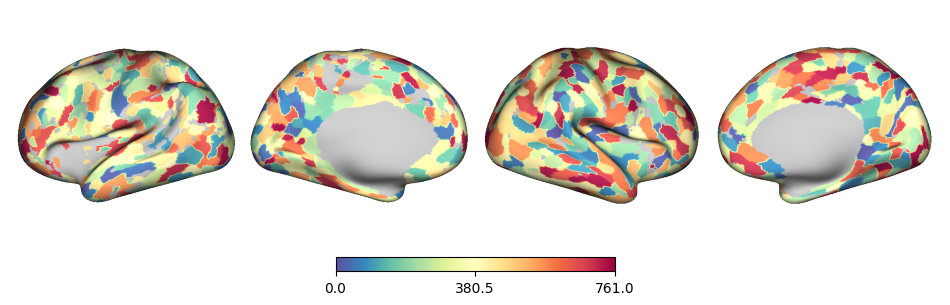

In [42]:
ax, _ = pm.plot.vertex_plot(sfv, **vp_kwargs)

In [46]:
template_cifti

In [57]:
dsfv = pm.spatial_filtering.wb_dilate(sfv, template_cifti_path, max_size=50)

In [66]:
dsfv = pm.spatial_filtering.spatial_filter_and_dilate(test_pt_values, template_cifti_path, n_cpu=1, pbar=True, min_size=50)

  0%|          | 0/762 [00:00<?, ?it/s]

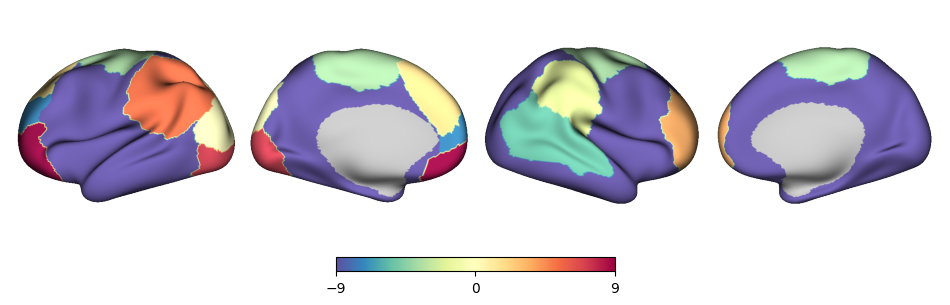

In [65]:
ax, _ = pm.plot.vertex_plot(dsfv, **vp_kwargs)

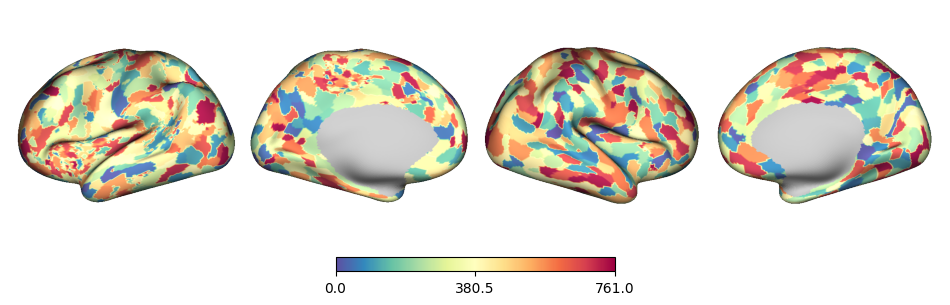

In [40]:
ax, _ = pm.plot.vertex_plot(test_pt_values, **vp_kwargs)

# Rewriting core sparse_correlator :(

In [4]:
import scipy
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [86]:
mask = scipy.sparse.load_npz(pm.constants.DEFAULT_MASK)

sparsity = 0.1
voxel_data = pm.cifti_tools.load_voxel_data(dtseries_path, censor_file=censor_file)
exclude_index = np.arange(voxel_data.shape[1]) >= 59_412

block_size=1000
leave=False
SC_kwargs = {}

backend = np
backend = torch

In [87]:
zmat = pm.sparse_correlator.top_row_correlations(voxel_data, sparsity=0.01, window_size=100, mask=mask,
                                                 backend="torch", device="mps", exclude_index=exclude_index, leave=False)
# scipy.sparse.save_npz(npz_path, zmat)

Top K Sparse Correlation:   0%|          | 0/913 [00:00<?, ?it/s]

In [30]:
scipy.sparse.save_npz(npz_path, zmat)

In [498]:
12574273 / 91282

137.75194452356433

In [474]:
scipy.sparse.save_npz(npz_path, zmat)

In [482]:
hmat = scipy.sparse.load_npz(npz_path)

In [480]:
zmat

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 83340466 stored elements and shape (91282, 91282)>

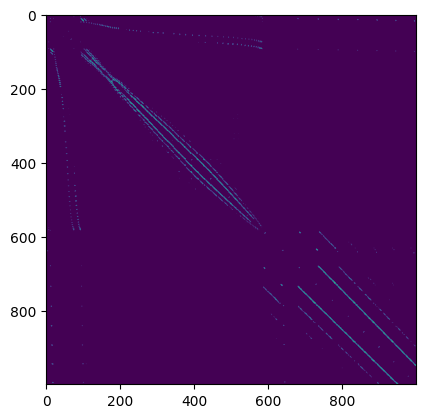

In [28]:
plt.imshow(zmat[:1000, :1000].todense())

In [270]:
x = pm.spc_utils.to_backend(backend, voxel_data)
y = pm.spc_utils.to_backend(backend, voxel_data)

x, y = x.T, y.T
x_demeaned = x - x.mean(axis=1, keepdims=True)
y_demeaned = y - y.mean(axis=1, keepdims=True)

x_norm = x_demeaned / backend.sqrt(backend.sum(x_demeaned ** 2, axis=1, keepdims=True))
y_norm = y_demeaned / backend.sqrt(backend.sum(y_demeaned ** 2, axis=1, keepdims=True))

n_vertices = y_norm.shape[0]
k_top_vertices = int(np.ceil(sparsity * y_norm.shape[0]))
k_top_vertices

913

In [429]:
window_size = 100

n_windows = int(np.ceil(y_norm.shape[0] / window_size))
c_x_indices, c_values = [], []
for i in tqdm(range(n_windows)):
    window_start_index = i * window_size
    window_end_index = window_start_index + window_size
    y_window_slice = slice(window_start_index, window_start_index + window_size)
    y_window = y_norm[y_window_slice]

    corr_window = (x_norm @ y_window.T)
    # excludes diagonal
    corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0
    # excludes exclude_index
    corr_window[exclude_index] = 0

    # excludes mask
    mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
    mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)
    corr_window = corr_window * mask_window
    
    cw_values, cw_x_indices = pm.spc_utils.MPS_safe_topk(backend, device_info, corr_window, k_top_vertices, axis=0)
    c_x_indices.append(cw_x_indices)
    c_values.append(cw_values)
    
    if i > -1:
        break

c_values = backend.concat(c_values, axis=1)
c_x_indices = backend.concat(c_x_indices, axis=1)
c_y_indices = backend.arange(n_vertices).tile(k_top_vertices, 1)

  0%|          | 0/913 [00:00<?, ?it/s]

In [430]:
mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)

In [431]:
mask_window.shape

torch.Size([91282, 100])

In [432]:
corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0

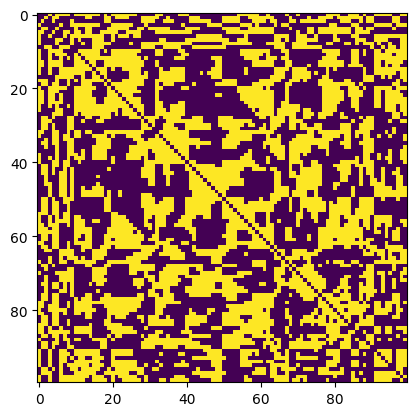

In [433]:
plt.imshow(corr_window[y_window_slice, :window_size] > 0)

In [365]:
z = corr_window * mask_window

In [366]:
torch.sum(z[:, 0] > 0)

tensor(45908)

In [275]:
corr_window[exclude_index] = 0

In [276]:
corr_window

tensor([[ 1.4445e-01,  5.1904e-01,  6.8831e-01,  ..., -3.6970e-01,
          1.1788e-01,  2.3520e-01],
        [-6.9083e-01,  4.6165e-01,  2.7206e-01,  ..., -1.2637e-01,
         -3.9806e-01,  5.3681e-01],
        [-4.8422e-01, -2.0935e-01, -5.3943e-01,  ...,  3.8183e-01,
         -4.8683e-01,  3.2666e-05],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

In [220]:
c_x_indices = c_x_indices.ravel()
c_y_indices = c_y_indices.ravel()
c_values = c_values.ravel()

In [221]:
tv, ri, ci = pm.spc_utils.to_np((c_values, c_x_indices, c_y_indices))

In [222]:
zmat = scipy.sparse.csr_matrix((tv, (ri.astype(int), ci.astype(int))), shape=(n_vertices, n_vertices))

In [224]:
scipy.sparse.save_npz(npz_path, sc)

In [208]:
pm.spc_utils.get_nnz_safe(zmat)

83340466

In [85]:
x_norm.shape, y_norm.shape, yns.shape

(torch.Size([91282, 29]), torch.Size([91282, 29]), torch.Size([3, 29]))

In [101]:
z = (x_norm @ yns.T)
print(z.shape)

torch.Size([91282, 3])


In [102]:
device_info = pm.spc_utils.get_device_info(backend, "cpu")

In [103]:
k_top_vertices = int(np.ceil(sparsity * voxel_data.shape[1]))

In [106]:
pm.spc_utils.MPS_safe_topk(backend, device_info, z, k_top_vertices, axis=0)[0].shape

torch.Size([913, 3])

In [107]:
z[np.argsort(z[:, 0])[-k_top_vertices:], 0]

tensor([0.8260, 0.8260, 0.8260, 0.8260, 0.8260, 0.8261, 0.8261, 0.8262, 0.8262,
        0.8262, 0.8263, 0.8263, 0.8266, 0.8266, 0.8267, 0.8267, 0.8268, 0.8268,
        0.8268, 0.8269, 0.8271, 0.8273, 0.8273, 0.8273, 0.8273, 0.8274, 0.8274,
        0.8275, 0.8275, 0.8275, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276,
        0.8277, 0.8277, 0.8277, 0.8278, 0.8279, 0.8280, 0.8280, 0.8281, 0.8282,
        0.8282, 0.8282, 0.8285, 0.8286, 0.8286, 0.8286, 0.8287, 0.8287, 0.8288,
        0.8289, 0.8289, 0.8289, 0.8290, 0.8291, 0.8291, 0.8293, 0.8293, 0.8294,
        0.8295, 0.8296, 0.8297, 0.8298, 0.8298, 0.8298, 0.8299, 0.8299, 0.8299,
        0.8300, 0.8301, 0.8301, 0.8301, 0.8301, 0.8302, 0.8302, 0.8303, 0.8303,
        0.8303, 0.8304, 0.8305, 0.8305, 0.8307, 0.8307, 0.8307, 0.8309, 0.8309,
        0.8310, 0.8312, 0.8313, 0.8313, 0.8313, 0.8313, 0.8314, 0.8314, 0.8314,
        0.8315, 0.8315, 0.8316, 0.8316, 0.8316, 0.8317, 0.8318, 0.8319, 0.8319,
        0.8320, 0.8320, 0.8320, 0.8320, 

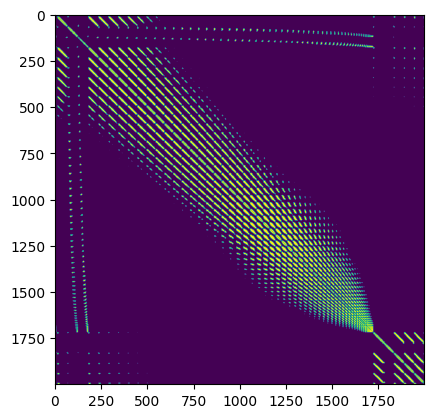

In [333]:
plt.imshow(pm.spc_utils.sparse_to_array(mask[:2000, :2000]))

In [21]:

sc = pm.sparse_correlator.SparseCorrelator.run(voxel_data, sparsity_percent=sparsity, symmetric=True,
                          mask=mask, exclude_index=exclude_index,
                          block_size=block_size, leave=leave, **SC_kwargs)

SparseCorrelator Block Analysis:   0%|          | 0/4278.0 [00:00<?, ?it/s]

In [3]:
from precision_mapping import functional_connectivity as fc

In [4]:
fc.generate_correlation_matrix(TEST_DTSERIES_PATH, TEST_OUTPUT_VERTEX_FC_PATH,
                               censor_file=TEST_DTSERIES_CENSOR_FILE,
                               sparsity=0.01,
                               exclude_index_path=None,
                               mask=30,
                                block_size=2_000,
                                overwrite=True, leave=True)

SparseCorrelator Block Analysis:   0%|          | 0/4324.0 [00:00<?, ?it/s]

'/System/Volumes/Data/data/data7/network_control/projects/precision_mapping/tests/outputs/example_vertex_FC.npz'

# Multi layer infomaps flow test

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import glob
import scipy
import itertools

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns


from tqdm.auto import tqdm
from infomap import Infomap
from sklearn.metrics import normalized_mutual_info_score as nmis

sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import precision_mapping as pm

In [2]:
test_dir = "/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/"

network_partition_paths = glob.glob(test_dir + "*duration-25m*network_partition.npy")
pfm_parcel_partition_paths = glob.glob(test_dir + "*duration-25m*parcel_partition.npy")

pfm_vfc_paths = glob.glob(test_dir + "*duration-25m*FC.npz")
hcp_vfc_paths = glob.glob("/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/*/*_rfMRI_REST_7T_ALL_*.npz")

In [3]:
hcp_parcel_partition_paths = glob.glob("/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/*/*_rfMRI_REST_7T_ALL_*parcel_partition.npy")

In [4]:
def load_partitions(parcel_partition_paths):
    parcel_partitions = [np.load(p) for p in parcel_partition_paths]
    parcel_partitions = np.array([p[1] for p in parcel_partitions])
    return parcel_partitions[:, ~np.isnan(parcel_partitions).any(axis=0)].astype(int)
    
def calculate_overlap_score_from_npy(parcel_partition_paths, metric=nmis):
    """ """
    parcel_partitions = load_partitions(parcel_partition_paths)
    scores = [metric(p1, p2) for p1, p2 in list(itertools.combinations(parcel_partitions, 2))]
    return scores

def mean_dice_score(z, h):
    dice_s = [2 * np.sum((z == i) & (h == i)) / (np.sum(z == i) + np.sum(h == i)) for i in np.sort(np.unique(z))]
    return np.mean(dice_s)

def accuracy(z, h):
    return np.mean(z == h) * 100

def co_cluster_percent(p1, p2):
    return np.sum([np.max(np.unique(p2[p1 == i], return_counts=True)[1]) for i in np.unique(p1)]) / len(p1) * 100

In [5]:
def calculate_overlap_score_npz(vfc_paths=None, save_csv_path=None, overwrite=False, metric=nmis, mlr_rate=0.15):
    """ """

    if vfc_paths is not None and (overwrite or save_csv_path is None or (not os.path.exists(save_csv_path))):
        sparse_vFC_s = [scipy.sparse.load_npz(p) for p in vfc_paths]
    
        matrices = sparse_vFC_s    
        im = Infomap(multilayer_relax_limit=1, multilayer_relax_rate=mlr_rate, no_self_links=True, clu_level=2)
        n = np.sum([vfc.nnz for vfc in matrices])
        
        for layer, matrix in enumerate(matrices):
            pbar = tqdm(desc="Adding links", total=matrix.nnz, leave=True)
            for r_i, c_i, fc_i in zip(*matrix.nonzero(), matrix.data):
                im.add_multilayer_intra_link(layer, r_i, c_i, weight=fc_i)
                pbar.update(1)
            pbar.close()
    
        im.run(num_trials=1)
    
        # partition_df = []
        # for node in im.nodes:
        #     partition_df.append([node.module_id, node.layer_id, node.node_id])
        # partition_df = pd.DataFrame(partition_df, columns=["mod", "layer", "node"])

        partition_df = pd.DataFrame([[node.physicalId, node.stateId, node.layerId] for node in im.iterTree()],
                 columns=["physical_id", "state_id", "layer"])
        partition_df = partition_df.drop_duplicates()
        
        mdl1 = im.get_modules(depth_level=1, states=True)
        mdl2 = im.get_modules(depth_level=2, states=True)
        
        partition_df["mod_depth1"] = partition_df["state_id"].map(mdl1.get)
        partition_df["mod_depth2"] = partition_df["state_id"].map(mdl2.get)
    
        if save_csv_path:
            partition_df.to_csv(save_csv_path)
    else:
        partition_df = pd.read_csv(save_csv_path)

    partition_array = np.full((len(partition_df["layer"].unique()), 91_282), fill_value=np.nan)
    for layer, df in partition_df.groupby("layer"):
        partition_array[layer][df["physical_id"]] = df["mod_depth2"]
    partition_array = partition_array[:, ~np.isnan(partition_array).any(axis=0)]
    
    imf_scores = [metric(p1, p2) for p1, p2 in list(itertools.combinations(partition_array, 2))]
    return imf_scores, partition_df #, im

In [6]:
# _, hcp_tdf = calculate_overlap_score_npz(hcp_vfc_paths, overwrite=False, mlr_rate=0.05)

In [7]:
subject_ids, sample_labels = [], []
dtseries_paths, censor_files = [], []
for p in pfm_parcel_partition_paths:
    subject_ids.append(p.split("/")[6])
    sample_labels.append(p.split("/")[-1].split("_parcel")[0] + "_IMF")
    
    dtseries_path_i = os.path.dirname(p) + "/bolddata/" + os.path.basename(p).split("_parcel")[0] + ".dtseries.nii"
    assert os.path.exists(dtseries_path_i)
    censor_file_i = dtseries_path_i.replace("bolddata", "frcnsr_lists").split("_space")[0] + "_include.dat"
    assert os.path.exists(censor_file_i)
    
    dtseries_paths.append(dtseries_path_i)
    censor_files.append(censor_file_i)

out_dir = os.path.dirname(p) + "/pfm_IMF/"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [8]:
paths = pm.utils.create_pm_paths(subject_ids, sample_labels, out_dir, method="infomaps")

In [9]:
pfm_pdf

NameError: name 'pfm_pdf' is not defined

In [10]:
_, pfm_pdf = calculate_overlap_score_npz(save_csv_path="imf_save.csv")

pfm_imf_partitions = []
for i, parcel_partition_path in enumerate(paths["parcel-partition"]):
    layer_partition_df = pfm_pdf.loc[pfm_pdf["layer"] == i].sort_values("physical_id")
    indices = layer_partition_df["physical_id"].values
    groups = layer_partition_df["mod_depth2"].values
    
    pfm_imf_partitions.append((indices, groups))
    pm.parcellate.save_partition(indices, groups, parcel_partition_path)

In [27]:
overwrite = False
pm.na.assign_networks_batch(dtseries_paths, paths["parcel-partition"], paths["network-partition"], censor_files=censor_files, overwrite=overwrite)

o_kwargs = dict(template_cifti=dtseries_paths[0], overwrite=overwrite)
pm.partition_tools.write_parcel_dlabel(paths["parcel-partition"], paths["parcel-dlabel"], **o_kwargs)
pm.partition_tools.write_network_dlabel(paths["network-partition"], paths["network-dlabel"], **o_kwargs)
pm.partition_tools.calculate_network_surface_areas(paths["network-partition"], paths["network-size-csv"], **o_kwargs)
pm.plot.QC_plots(paths["parcel-partition"], save_path=paths["qc-plot"], overwrite=overwrite)
pm.plot.parcel_plot(paths["parcel-partition"], paths["network-partition"],
                 sample_labels, paths["parcel-plot"], **o_kwargs)

Assigning parcellation networks:   0%|          | 0/3 [00:00<?, ?cifti/s]

/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508131400_task-rest_duration-25m_num-1_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508281400_task-rest_duration-25m_num-2_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2510021400_task-rest_duration-25m_num-3_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_partition.npy already exists and no '--overwrite' flag given. Skipping network assignment.


Writing parcel dlabel:   0%|          | 0/3 [00:00<?, ?it/s]

/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508131400_task-rest_duration-25m_num-1_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_parcels.dlabel.nii already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508281400_task-rest_duration-25m_num-2_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_parcels.dlabel.nii already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2510021400_task-rest_duration-25m_num-3_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_parcels.dlabel.nii already exists, skipping. Can use --overwrite to overwrite.


Writing network dlabel:   0%|          | 0/3 [00:00<?, ?it/s]

...

Writing network size csvs:   0%|          | 0/3 [00:00<?, ?it/s]

/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508131400_task-rest_duration-25m_num-1_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_sizes.csv already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508281400_task-rest_duration-25m_num-2_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_sizes.csv already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2510021400_task-rest_duration-25m_num-3_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_network_sizes.csv already exists, skipping. Can use --overwrite to overwrite.


Generating QC plots:   0%|          | 0/3 [00:00<?, ?it/s]

/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508131400_task-rest_duration-25m_num-1_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_QC_plot.png already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2508281400_task-rest_duration-25m_num-2_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_QC_plot.png already exists, skipping. Can use --overwrite to overwrite.
/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/pfm_IMF/sub-pfmsb001/sub-pfmsb001_ses-2510021400_task-rest_duration-25m_num-3_space-fsLR_den-91k_desc-denoisedSmoothed_bold_IMF_QC_plot.png already exists, skipping. Can use --overwrite to overwrite.


Generating parcel plots:   0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
np.unique([10, 5, 5, 10, 1], return_counts=True, return_index=True)

(array([ 1,  5, 10]), array([4, 1, 0]), array([1, 2, 2]))

# Overlap Score Analysis 

In [29]:
_, tdf = calculate_overlap_score_npz(pfm_vfc_paths, save_csv_path="imf_save.csv", overwrite=False)
_, hdf = calculate_overlap_score_npz(hcp_vfc_paths, save_csv_path="imf_hcp_save.csv", overwrite=False)

In [30]:
tdf["mod_depth2"].max(), hdf["mod_depth2"].max()

(np.int64(553), np.int64(745))

In [62]:
mlr_rate_s = [0.0, 0.01, 0.05, 0.10, 0.5]
hcp_imf_ccp_mlr_scores = {}
pfm_imf_ccp_mlr_scores = {}
pbar = tqdm(desc="Running MLR tests", total=2 * len(mlr_rate_s))

for mlr_rate in mlr_rate_s:
    mlr_rate_str = f"{mlr_rate:.02f}"[-2:]
    # if not os.path.exists(f"imf_hcp_save_mlr_{mlr_rate_str}.csv"):
    #     continue
    hcp_imf_mlr_ccp_score, _ = calculate_overlap_score_npz(hcp_vfc_paths, save_csv_path=f"imf_hcp_save_mlr_{mlr_rate_str}.csv",
                                      overwrite=False, mlr_rate=mlr_rate, metric=co_cluster_percent)
    hcp_imf_ccp_mlr_scores[mlr_rate] = hcp_imf_mlr_ccp_score
    pbar.update(1)

for mlr_rate in mlr_rate_s:
    mlr_rate_str = f"{mlr_rate:.02f}"[-2:]
    pfm_imf_mlr_ccp_score, _ = calculate_overlap_score_npz(pfm_vfc_paths, save_csv_path=f"imf_pfm_save_mlr_{mlr_rate_str}.csv",
                                                           overwrite=False, mlr_rate=mlr_rate, metric=co_cluster_percent)
    pfm_imf_ccp_mlr_scores[mlr_rate] = pfm_imf_mlr_ccp_score
    pbar.update(1)

Running MLR tests:   0%|          | 0/10 [00:00<?, ?it/s]

In [64]:
pfm_imi_nmis_scores = calculate_overlap_score_from_npy(pfm_parcel_partition_paths)
hcp_imi_nmis_scores = calculate_overlap_score_from_npy(hcp_parcel_partition_paths)

pfm_imf_nmis_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv")
hcp_imf_nmis_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", overwrite=False)

In [65]:
pfm_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv", metric=accuracy)
hcp_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", metric=accuracy)

pfm_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_save.csv", metric=co_cluster_percent)
hcp_imf_ccp_scores, _ = calculate_overlap_score_npz(save_csv_path="imf_hcp_save.csv", metric=co_cluster_percent)

pfm_imi_ccp_scores = calculate_overlap_score_from_npy(pfm_parcel_partition_paths, metric=co_cluster_percent)
hcp_imi_ccp_scores = calculate_overlap_score_from_npy(hcp_parcel_partition_paths, metric=co_cluster_percent)

In [66]:
cdf = pd.DataFrame({"Individual - PFM Subject": pfm_imi_ccp_scores,
                    "Individual - Random HCP:7T Subjects": hcp_imi_ccp_scores,
                   "Multilayer Flow - PFM Subject":pfm_imf_ccp_scores,
                   "Multilayer Flow - Random HCP:7T Subjects":hcp_imf_ccp_scores,
                   "x": np.arange(3)})

cd = cdf.melt(id_vars=["x"])
cd["method"] = cd["variable"].str.split("-").str[0].str.strip()
cd["samples"] = cd["variable"].str.split("-").str[1].str.strip()

In [117]:
cd

,x,variable,value,method,samples
0,0,Individual - PFM Subject,63.460630,Individual,PFM Subject
1,1,Individual - PFM Subject,59.408759,Individual,PFM Subject
2,2,Individual - PFM Subject,60.196714,Individual,PFM Subject
3,0,Individual - Random HCP:7T Subjects,55.347166,Individual,Random HCP:7T Subjects
4,1,Individual - Random HCP:7T Subjects,56.808571,Individual,Random HCP:7T Subjects
5,2,Individual - Random HCP:7T Subjects,55.881773,Individual,Random HCP:7T Subjects
6,0,Multilayer Flow - PFM Subject,98.435079,Multilayer Flow,PFM Subject
7,1,Multilayer Flow - PFM Subject,97.639431,Multilayer Flow,PFM Subject
8,2,Multilayer Flow - PFM Subject,97.616353,Multilayer Flow,PFM Subject
9,0,Multilayer Flow - Random HCP:7T Subjects,99.213427,Multilayer Flow,Random HCP:7T Subjects


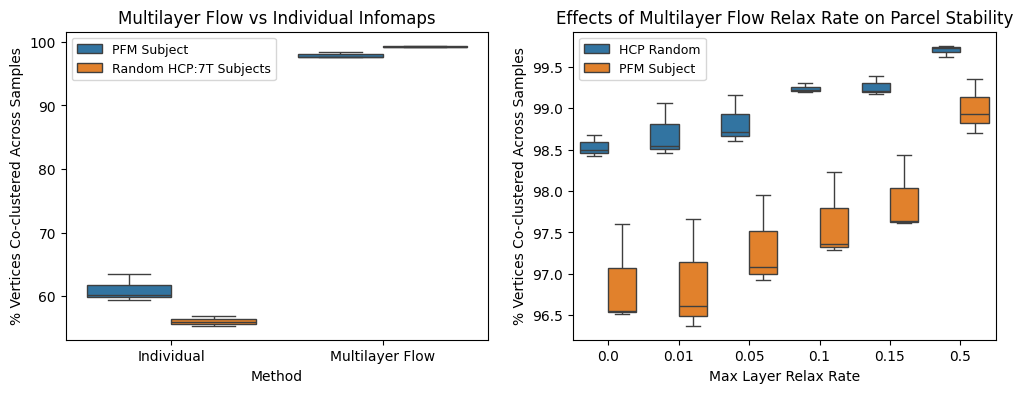

In [144]:
hmdf = pd.DataFrame(hcp_imf_ccp_mlr_scores)
pmdf = pd.DataFrame(pfm_imf_ccp_mlr_scores)
hmdf[0.15] = hcp_imf_ccp_scores
pmdf[0.15] = pfm_imf_ccp_scores

hmdf = hmdf.assign(Group="HCP Random").melt(id_vars=["Group"], var_name="mlr", value_name="ccp")
pmdf = pmdf.assign(Group="PFM Subject").melt(id_vars=["Group"], var_name="mlr", value_name="ccp")

mdf = pd.concat([hmdf, pmdf], axis=0)
fig, (ax1, ax) = plt.subplots(1, 2, figsize=(12, 4))
# fig.tight_layout(w_pad=10)
sns.boxplot(data=mdf, x="mlr", y="ccp", hue="Group", ax=ax)
ax.set(xlabel="Max Layer Relax Rate", ylabel="% Vertices Co-clustered Across Samples")
ax.set_title("Effects of Multilayer Flow Relax Rate on Parcel Stability")
ax.legend(fontsize=9)

sns.boxplot(data=cd, x="method", y="value", hue="samples", ax=ax1)
ax1.set(xlabel="Method", ylabel="% Vertices Co-clustered Across Samples")
ax1.set_title("Multilayer Flow vs Individual Infomaps")
ax1.legend(fontsize=9)

In [70]:
sdf = pd.DataFrame({
                   "Individual - PFM Subject": pfm_imi_nmis_scores,
                   "Multilayer Flow - PFM Subject":pfm_imf_nmis_scores,
                   "Individual - Random HCP:7T Subjects": hcp_imi_nmis_scores,
                   "Multilayer Flow - Random HCP:7T Subjects":hcp_imf_nmis_scores,
                   "x": np.arange(3)})
sd = sdf.melt(id_vars=["x"])
sd["method"] = sd["variable"].str.split("-").str[0].str.strip()
sd["samples"] = sd["variable"].str.split("-").str[1].str.strip()
sd

,x,variable,value,method,samples
0,0,Individual - PFM Subject,0.815474,Individual,PFM Subject
1,1,Individual - PFM Subject,0.807780,Individual,PFM Subject
2,2,Individual - PFM Subject,0.809917,Individual,PFM Subject
3,0,Multilayer Flow - PFM Subject,0.987120,Multilayer Flow,PFM Subject
4,1,Multilayer Flow - PFM Subject,0.981816,Multilayer Flow,PFM Subject
5,2,Multilayer Flow - PFM Subject,0.981677,Multilayer Flow,PFM Subject
6,0,Individual - Random HCP:7T Subjects,0.747415,Individual,Random HCP:7T Subjects
7,1,Individual - Random HCP:7T Subjects,0.757820,Individual,Random HCP:7T Subjects
8,2,Individual - Random HCP:7T Subjects,0.765780,Individual,Random HCP:7T Subjects
9,0,Multilayer Flow - Random HCP:7T Subjects,0.994451,Multilayer Flow,Random HCP:7T Subjects


(53.14519839617888, 109.0)

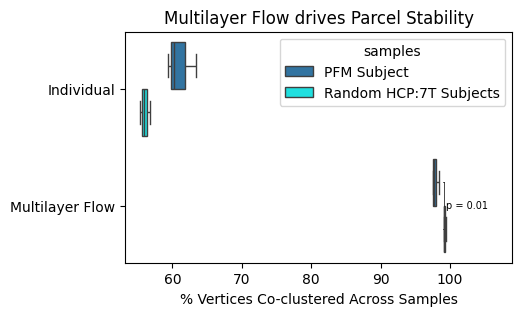

In [74]:
fig, a1 = plt.subplots(figsize=(5, 3))

sns.boxplot(data=cd, y="method", x="value", hue="samples", palette=["C0", "cyan"], ax=a1)
a1.set(ylabel="", xlabel="% Vertices Co-clustered Across Samples")
a1.set_title("Multilayer Flow drives Parcel Stability")

t, p = scipy.stats.ttest_ind(cd.query("variable == 'Multilayer Flow - Random HCP:7T Subjects'")["value"],
                      cd.query("variable == 'Multilayer Flow - PFM Subject'")["value"])

a1.plot([99.1, 99.1], [0.8, 1.2], color="k", linewidth=0.5)
a1.plot([99.05, 99.1], [1.2, 1.2], color="k", linewidth=0.5)
a1.plot([99.05, 99.1], [.8, 0.8], color="k", linewidth=0.5)
a1.text(99.5, 1, f"p = {p:.2f}", va="center", ha="left", fontsize=7, rotation=0)
a1.set_xlim(None, 109)

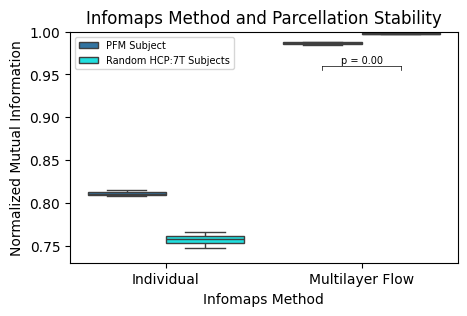

In [49]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.boxplot(data=sd, x="method", y="value", hue="samples", ax=ax, palette=["C0", "cyan"])
# sns.swarmplot(data=sd, x="method", y="value", hue="samples", ax=ax, palette=["C0", "cyan"])
ax.set(ylabel="Normalized Mutual Information", xlabel="Infomaps Method")
ax.set_title("Infomaps Method and Parcellation Stability")
# ax.tick_params(axis='x', labelrotation=45)
# ax.set_ylim(0, 1.05)

t, p = scipy.stats.ttest_ind(sd.query("variable == 'Multilayer Flow - Random HCP:7T Subjects'")["value"],
                      sd.query("variable == 'Multilayer Flow - PFM Subject'")["value"])

ax.plot([0.8, 1.2], [0.96, 0.96], color="k", linewidth=0.5)
ax.plot([0.8, 0.8], [0.955, 0.96], color="k", linewidth=0.5)
ax.plot([1.2, 1.2], [0.955, 0.96], color="k", linewidth=0.5)
ax.text(1, 0.961, f"p = {p:.2f}", va="bottom", ha="center", fontsize=7)
ax.set_ylim(0.73, 1.0)
ax.legend(fontsize=7)


In [38]:
t, p = scipy.stats.ttest_ind(sd.query("variable == 'Singlelayer - Random HCP:7T Subjects'")["value"],
                      sd.query("variable == 'Singlelayer - PFM Subject'")["value"])
t,p

(np.float64(-1.613352227862102), np.float64(0.18196529839433068))

In [195]:
network_partitions = [np.load(p) for p in network_partition_paths]
parcel_partitions = [np.load(p) for p in parcel_partition_paths]
parcel_partitions = np.array([p[1] for p in parcel_partitions])
parcel_partitions = parcel_partitions[:, ~np.isnan(parcel_partitions).any(axis=0)].astype(int)

hcp_parcel_partitions = [np.load(p) for p in hcp_parcel_partition_paths]
hcp_parcel_partitions = np.array([p[1] for p in hcp_parcel_partitions])
hcp_parcel_partitions = hcp_parcel_partitions[:, ~np.isnan(hcp_parcel_partitions).any(axis=0)].astype(int)
sparse_vFC_s = [scipy.sparse.load_npz(p) for p in vfc_paths]

NameError: name 'parcel_partition_paths' is not defined

In [329]:
z = network_partitions[0][0].astype(int)
h = network_partitions[1][0].astype(int)
g = network_partitions[2][0].astype(int)

In [331]:
imi_d_s = [nmis(parcel_partitions[0], np) for np in parcel_partitions]
imi_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(parcel_partitions, 2))]

imi_hcp_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(hcp_parcel_partitions, 2))]

In [332]:
from infomap import Infomap

In [274]:
matrices = sparse_vFC_s

im = Infomap(multilayer_relax_limit=1)
n = np.sum([vfc.nnz for vfc in matrices])

for layer, matrix in enumerate(matrices):
    # matrix = matrix[:5000, :5000]
    # nodes = tuple((layer * matrix.shape[0] + i, f"l{layer}_{i}") for i in range(matrix.shape[0]))
    # im.add_nodes(nodes)
    pbar = tqdm(desc="Adding links", total=matrix.nnz, leave=False)
    # for r_i, c_i in zip(*matrix.nonzero()):
    print(len(matrix.data))
    for r_i, c_i, fc_i in zip(*matrix.nonzero(), matrix.data):
        # matrix[r_i, c_i]
        im.add_multilayer_intra_link(layer, r_i, c_i, weight=fc_i)
        pbar.update(1)
    pbar.close()

Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


Adding links:   0%|          | 0/8397944 [00:00<?, ?it/s]

8397944


In [276]:
im.run(num_trials=1)

. Found 6 levels with codelength 8.810062358

=> Trial 1/1 finished in 357.881514s with codelength 8.81006236


Summary after 1 trial
Best end modular solution in 6 levels:
Per level number of modules:         [          6,         240,        2773,        1760,         141,           0] (sum: 4920)
Per level number of leaf nodes:      [          0,           0,       10579,      176954,       82601,        3712] (sum: 273846)
Per level average child degree:      [          6,          40,     55.6333,     64.4479,     47.0125,     26.3262] (average: 58.3207)
Per level codelength for modules:    [0.025894546, 0.518942739, 1.612139210, 0.587119799, 0.023156288, 0.000000000] (sum: 2.767252582)
Per level codelength for leaf nodes: [0.000000000, 0.000000000, 0.262255605, 4.066631136, 1.651026150, 0.062896886] (sum: 6.042809777)
Per level codelength total:          [0.025894546, 0.518942739, 1.874394815, 4.653750935, 1.674182438, 0.062896886] (sum: 8.810062358)

  Infomap ends at 2026-01-15

In [372]:
r = []
for node in im.nodes:
    r.append([node.module_id, node.layer_id, node.node_id])
r = pd.DataFrame(r, columns=["mod", "layer", "node"])
# r.to_csv("imf_hcp_save.csv")
r = pd.read_csv("imf_save.csv")
# r = pd.read_csv("imf_hcp_save.csv")

In [373]:
v = np.full((len(matrices), matrix.shape[0]), fill_value=np.nan)

for layer, df in r.groupby("layer"):
    v[layer][df["node"]] = df["mod"]
v = v[:, ~np.isnan(v).any(axis=0)]

In [374]:
imf_combos_d_s = [calc_mean_dice(p1, p2) for p1, p2 in list(itertools.combinations(v, 2))]
imf_combos_d_s

[np.float64(0.980599076643026),
 np.float64(0.9755289300158059),
 np.float64(0.9752026984638159)]

In [301]:
imf_d_s = [nmis(v[0], v_i) for v_i in v]
imf_combos_d_s = [nmis(p1, p2) for p1, p2 in list(itertools.combinations(v, 2))]

In [302]:
imf_combos_d_s

[np.float64(0.8598098538759791),
 np.float64(0.8597494616565093),
 np.float64(0.8923214435226252)]

In [305]:
# np.save("imf_hcp_combos_d_s.npy", imf_combos_d_s)
# np.save("imf_combos_d_s.npy", imf_combos_d_s)
imf_combos_d_s = np.load("imf_combos_d_s.npy")
imf_hcp_combos_d_s = np.load("imf_hcp_combos_d_s.npy")

In [307]:
imf_combos_d_s, imf_hcp_combos_d_s

(array([0.94347052, 0.93161125, 0.93062284]),
 array([0.85980985, 0.85974946, 0.89232144]))

In [308]:
import itertools

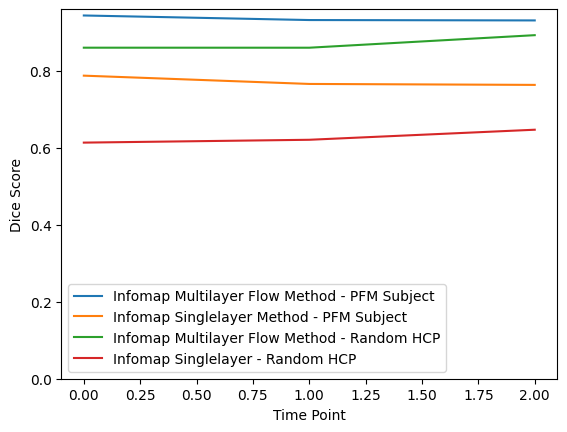

In [333]:
fig, ax = plt.subplots()
ax.plot(imf_combos_d_s, label="Infomap Multilayer Flow Method - PFM Subject")
ax.plot(imi_combos_d_s, label="Infomap Singlelayer Method - PFM Subject")
ax.plot(imf_hcp_combos_d_s, label="Infomap Multilayer Flow Method - Random HCP")
ax.plot(imi_hcp_combos_d_s, label="Infomap Singlelayer - Random HCP")
ax.legend()
ax.set_ylim(0, None)
ax.set(xlabel="Time Point", ylabel="Dice Score")
fig.savefig("infomap_flow_comparisons.png")

In [381]:
sd = pd.DataFrame({
                   "Singlelayer - PFM Subject": imi_combos_d_s,
                   "Multilayer Flow - PFM Subject":imf_combos_d_s,
                   "Singlelayer - Random HCP Subjects": imi_hcp_combos_d_s,
                   "Multilayer Flow - Random HCP Subjects":imf_hcp_combos_d_s,
                   "x": np.arange(3)})
sd = sd.melt(id_vars=["x"])
sd

sd["method"] = sd["variable"].str.split("-").str[0].str.strip()
sd["samples"] = sd["variable"].str.split("-").str[1].str.strip()
sd

,x,variable,value,method,samples
0,0,Singlelayer - PFM Subject,0.787181,Singlelayer,PFM Subject
1,1,Singlelayer - PFM Subject,0.765647,Singlelayer,PFM Subject
2,2,Singlelayer - PFM Subject,0.763175,Singlelayer,PFM Subject
3,0,Multilayer Flow - PFM Subject,0.980599,Multilayer Flow,PFM Subject
4,1,Multilayer Flow - PFM Subject,0.975529,Multilayer Flow,PFM Subject
5,2,Multilayer Flow - PFM Subject,0.975203,Multilayer Flow,PFM Subject
6,0,Singlelayer - Random HCP Subjects,0.613253,Singlelayer,Random HCP Subjects
7,1,Singlelayer - Random HCP Subjects,0.620627,Singlelayer,Random HCP Subjects
8,2,Singlelayer - Random HCP Subjects,0.646748,Singlelayer,Random HCP Subjects
9,0,Multilayer Flow - Random HCP Subjects,0.859810,Multilayer Flow,Random HCP Subjects


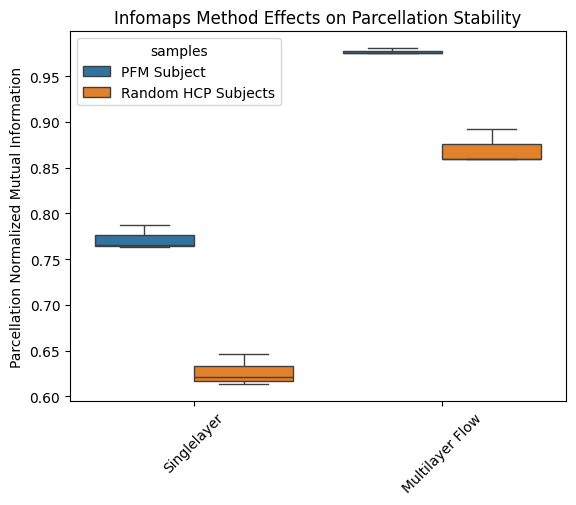

In [382]:
fig, ax = plt.subplots()
# sns.boxplot(data=sd, x="samples", y="value", hue="method", ax=ax)
# ax.set(xlabel="Parcellation Normalized Mutual Information", ylabel="")

sns.boxplot(data=sd, x="method", y="value", hue="samples", ax=ax)
ax.set(ylabel="Parcellation Normalized Mutual Information", xlabel="")
ax.set_title("Infomaps Method Effects on Parcellation Stability")
ax.tick_params(axis='x', labelrotation=45)
# ax.set_ylim(0, 1.05)

<Axes: xlabel='x', ylabel='value'>

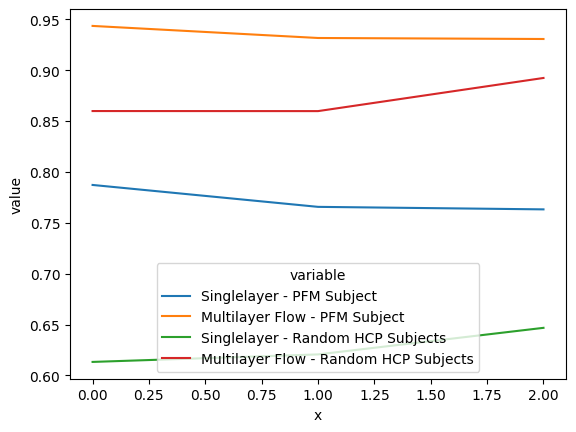

In [352]:
fig, ax = plt.subplots()
sns.lineplot(data=sd, x="x", y="value", hue="variable", ax=ax)

# Network Size Stability

In [105]:
imi_csv_paths = glob.glob(test_dir + "*duration-25m*.csv")
imi_df_s = [pd.read_csv(p).assign(layer=i) for i, p in enumerate(imi_csv_paths)]
imi_df_s = pd.concat([df.assign(p_area=df["area"] / df["area"].sum() * 100).assign(vp=df["vertex_count"]/59_412) for df in imi_df_s])

imf_csv_paths = glob.glob(test_dir + "pfm_IMF/sub-pfmsb001/*duration-25m*.csv")
imf_df_s = [pd.read_csv(p).assign(layer=i) for i, p in enumerate(imf_csv_paths)]
imf_df_s = pd.concat([df.assign(p_area=df["area"] / df["area"].sum() * 100).assign(vp=df["vertex_count"]/59_412) for df in imf_df_s])


In [234]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# fig.tight_layout(w_pad=20)
# sns.barplot(data=imi_df_s, x="p_area", y="network", hue="layer", ax=axes[0])
# sns.barplot(data=imf_df_s, x="p_area", y="network", hue="layer", ax=axes[1])

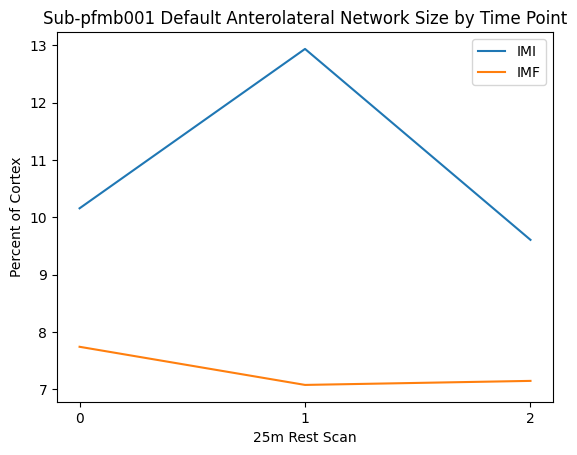

In [235]:
fig, ax = plt.subplots()
sns.lineplot(data=imi_df_s.query("network == 'Default_Anterolateral'"), x="layer", y="p_area", label="IMI", ax=ax)
sns.lineplot(data=imf_df_s.query("network == 'Default_Anterolateral'"), x="layer", y="p_area", label="IMF", ax=ax)

ax.set(title="Sub-pfmb001 Default Anterolateral Network Size by Time Point", xlabel="25m Rest Scan", ylabel="Percent of Cortex")
ax.set_xticks(range(3))

# RSFC Reliability PFM

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import glob
import scipy
import itertools

import numpy as np
import nibabel as nb
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import vertex as vfx
import precision_mapping as pm

In [2]:
pfm_full_dtseries = "/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/bolddata/sub-pfmsb001_task-rest_space-fsLR_den-91k_desc-denoisedSmoothed_bold.dtseries.nii"
pfm_full_dtseries = "/Users/cole/Downloads/sub-pfmsb001_task-rest_space-fsLR_den-91k_desc-denoisedSmoothed_bold.dtseries.nii"
pfm_censor_dat = "/data/data7/pfmsb_AAAV5170/analyses/precision_maps/sub-pfmsb001/frcnsr_lists/sub-pfmsb001_task-rest_include.dat"

TR_TIME = 1.08

In [3]:
full_voxel_data = pm.cifti_tools.load_voxel_data(pfm_full_dtseries, censor_file=pfm_censor_dat)

In [4]:
cortex = True
vd = full_voxel_data[:, :59_412] if cortex else full_voxel_data

In [5]:
def corr_pair(pair_data, axis=None, device="mps"):
    return vfx.FC.corr.pair_correlation(pair_data, axis=axis, leave=False, block_size=1000, backend="torch", device=device)

In [6]:
def vfx_reliability(vd, base_time=60, TR_TIME=1.08, axis=None, buffer_trs=30, device="mps"):
    """ """
    base_compare_trs = int((base_time *  60) // TR_TIME)

    r_s = []
    n_s = list(np.arange(0, len(vd) - base_compare_trs, int(np.ceil(5 * 60 / TR_TIME))))[1:]
    n_s = n_s + [len(vd) - base_compare_trs - buffer_trs]
    
    rand_r_s, chunk_r_s = [], []
    
    for n_compare_trs in tqdm(n_s, desc=f"Comparing subsections to {base_compare_trs * TR_TIME / 60:.1f} mins"):
        # base_vd, section_vd = vd[:base_compare_trs], vd[base_compare_trs:base_compare_trs + n_compare_trs]
        # pair_data = [base_vd, section_vd]
    
        tr_indices = np.arange(vd.shape[0])
        rand_base_indices = np.sort(np.random.choice(tr_indices, size=base_compare_trs, replace=False))
        remaining_tr_indices = tr_indices[~np.isin(tr_indices, rand_base_indices)]
        rand_compare_indices = np.sort(np.random.choice(remaining_tr_indices, size=n_compare_trs, replace=False))
    
        rand_r = corr_pair([vd[rand_base_indices], vd[rand_compare_indices]], axis=axis, device=device)
        print("rand_r", rand_r)
        rand_r_s.append(rand_r)
        
        chunk_r = corr_pair([vd[:base_compare_trs],
                             vd[buffer_trs + base_compare_trs:buffer_trs + base_compare_trs + n_compare_trs]], axis=axis, device=device)
        print("chunk_r", chunk_r)
        chunk_r_s.append(chunk_r)
    
    n_s = np.array(n_s)
    chunk_r_s = np.array(chunk_r_s)
    rand_r_s = np.array(rand_r_s)
    t_s = n_s * TR_TIME / 60

    return t_s, chunk_r_s, rand_r_s

In [8]:
pair_data = [vd[:2200], vd[2200:]]

In [109]:
pd1, pd2 = pair_data
noise_1 = np.random.randn(*pd1.shape)
noise_2 = np.random.randn(*pd2.shape)

# noisy_pair_data = ***

In [153]:
u1, sd1 = np.mean(pd1, axis=0), np.std(pd1, axis=0)
u2, sd2 = np.mean(pd2, axis=0), np.std(pd2, axis=0)
sd1[sd1 == 0] = 1
sd2[sd2 == 0] = 1

n_pd1 = (pd1 - u1) / sd1
n_pd2 = (pd2 - u2) / sd2

In [155]:
noise_fraction = 0.1

noise_weight = noise_fraction / (1 - noise_fraction)
noise_pair_data = [n_pd1 + noise_weight * noise_1, n_pd2 + noise_weight * noise_2]

In [156]:
ra_noise = corr_pair(noise_pair_data, axis=0)

PairCorrelatorAxis Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

In [124]:
ra = vfx.FC.corr.pair_correlation(pair_data, axis=0, leave=True, backend="torch", device="cpu")
ra.shape

PairCorrelatorAxis Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

(59412,)

In [160]:
nf_s = [0.0, 0.1, 0.5, 0.9]
rn_s = []
for noise_fraction in tqdm(nf_s):
    noise_weight = noise_fraction / (1 - noise_fraction)
    noise_pair_data = [n_pd1 + noise_weight * noise_1, n_pd2 + noise_weight * noise_2]
    rn = corr_pair(noise_pair_data)
    print(rn)
    rn_s.append(rn)

  0%|          | 0/4 [00:00<?, ?it/s]

PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

0.50912


KeyboardInterrupt: 

In [143]:
corr_pair(pair_data)

PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

np.float64(0.50912)

In [84]:
cortex = False
vd_axis = full_voxel_data
pfm_reliability_npy_path = "scratch/pfm_full_reliability_r_axis.npy"
if cortex:
    pfm_reliability_npy_path = pfm_reliability_npy_path.replace("_full", "")
    vd_axis = full_voxel_data[:, :59_412] 

if os.path.exists(pfm_reliability_npy_path):
    chunk_r_axis_s, rand_r_axis_s = np.load(pfm_reliability_npy_path)
    t_axis_s = np.load(pfm_reliability_npy_path.replace(".npy", "_time.npy"))
else:
    t_axis_s, chunk_r_axis_s, rand_r_axis_s = vfx_reliability(vd_axis, base_time=40, TR_TIME=1.08, axis=0, device="mps")
    np.save(pfm_reliability_npy_path, [chunk_r_axis_s, rand_r_axis_s])
    np.save(pfm_reliability_npy_path.replace(".npy", "_time.npy"), t_axis_s)

Comparing subsections to 40.0 mins:   0%|          | 0/8 [00:00<?, ?it/s]

PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

rand_r [0.91396046 0.89587724 0.85127604 ... 0.69718367 0.7051963  0.7050389 ]


PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

chunk_r [ 0.5074413   0.56242716  0.28556466 ... -0.02457521 -0.01499433
  0.12000363]


...

chunk_r [ 0.7062923   0.60197115  0.4562074  ... -0.02977673 -0.10752686
  0.1772513 ]


PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

rand_r [0.9740789  0.9705667  0.9513654  ... 0.8206015  0.82963526 0.87658036]


PairCorrelatorAxis Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

chunk_r [ 0.6934116   0.5890349   0.43560973 ... -0.02363232 -0.0623088
  0.18133621]


In [178]:
ls

dev_nb.ipynb                  imf_hcp_save.csv
examples.ipynb                imf_pfm_save_mlr_00.csv
imf_combos_d_s.npy            imf_pfm_save_mlr_01.csv
imf_hcp_combos_d_s.npy        imf_pfm_save_mlr_05.csv
imf_hcp_save_mlr_00.csv       imf_pfm_save_mlr_10.csv
imf_hcp_save_mlr_01.csv       imf_pfm_save_mlr_50.csv
imf_hcp_save_mlr_05.csv       imf_save.csv
imf_hcp_save_mlr_10.csv       infomap_flow_comparisons.png
imf_hcp_save_mlr_50.csv       pfm_pairwise_vfx.npy
imf_hcp_save_smoothed.csv     scratch/


In [177]:
np.save("pfm_pairwise_vfx.npy", chunk_r_axis_s[-1])

Text(0.5, 1.0, 'pfm-sub001 Splitwise Vertex FC Reliability (R^2)\n(2x 40 mins)')

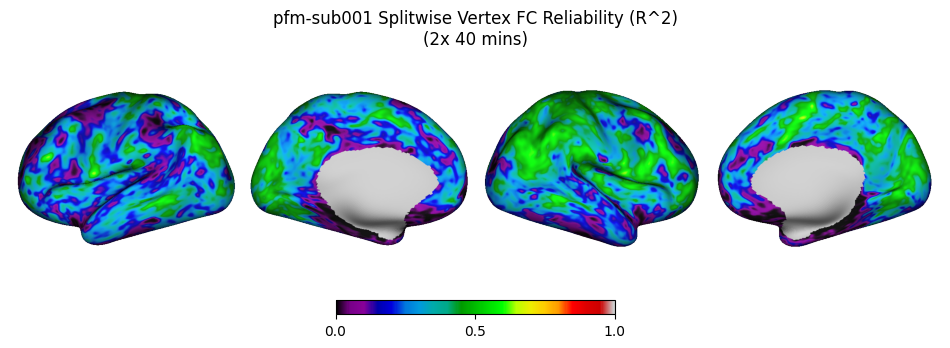

In [175]:
vp_kwargs = dict(template_cifti=template_cifti, color_range=[0, 1], cmap=plt.cm.nipy_spectral, cbar=True)
ax, _ = pm.plot.vertex_plot(chunk_r_axis_s[-1]**2, **vp_kwargs)
ax.set_title("pfm-sub001 Splitwise Vertex FC Reliability (R^2)\n(2x 40 mins)")

Text(0.5, 0.98, 'Vertex FC Reliability (R^2) Compared to 40 Mins')

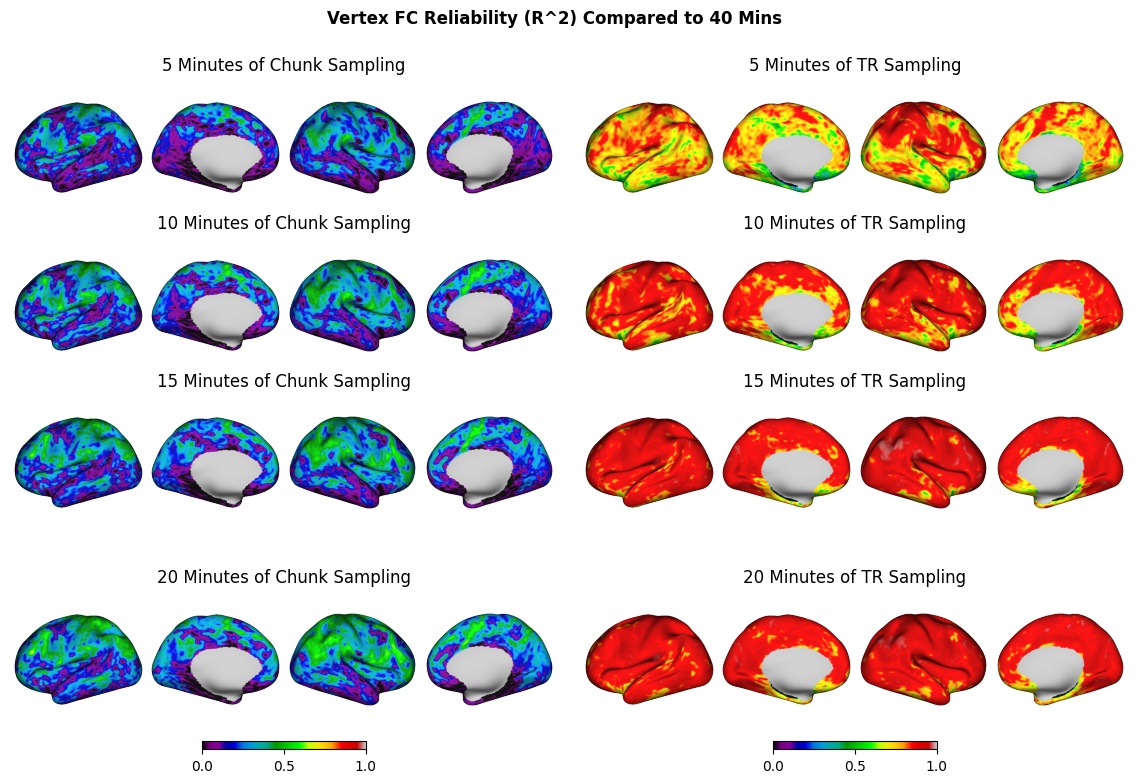

In [92]:
template_cifti = nb.load(pfm_full_dtseries)

cropped_t_axis_s = t_axis_s[:4]
fig, axes = plt.subplots(len(cropped_t_axis_s), 2, figsize=(12, len(cropped_t_axis_s) * 2))
axes = axes.reshape(len(cropped_t_axis_s), -1)
fig.tight_layout(h_pad=-10, w_pad=-2)
vp_kwargs = dict(template_cifti=template_cifti, color_range=[0, 1], cmap=plt.cm.nipy_spectral, cbar=False)

for i, row_axes in enumerate(axes):
    if i == len(cropped_t_axis_s) - 1:
        vp_kwargs["cbar"] = True

    pm.plot.vertex_plot(chunk_r_axis_s[i] ** 2, ax=row_axes[0], **vp_kwargs)
    pm.plot.vertex_plot(rand_r_axis_s[i] ** 2, ax=row_axes[1], **vp_kwargs)

    row_axes[0].set_title(f"{cropped_t_axis_s[i]:.0f} Minutes of Chunk Sampling")
    row_axes[1].set_title(f"{cropped_t_axis_s[i]:.0f} Minutes of TR Sampling")

fig.suptitle("Vertex FC Reliability (R^2) Compared to 40 Mins", fontweight="bold")

In [106]:
t_s, chunk_r_s, rand_r_s = vfx_reliability(vd, base_time=70, TR_TIME=1.08)

Comparing subsections to 70.0 mins:   0%|          | 0/2 [00:00<?, ?it/s]

PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

rand_r 0.85012


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

chunk_r 0.24818


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

KeyboardInterrupt: 

(0.0, 100.0)

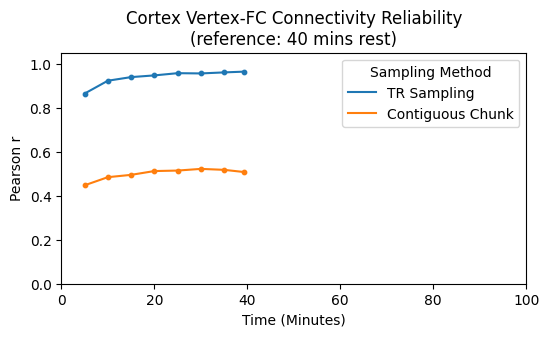

In [71]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(t_s, rand_r_s, label="TR Sampling")
ax.scatter(t_s, rand_r_s, s=10)

ax.plot(t_s, chunk_r_s, label="Contiguous Chunk")
ax.scatter(t_s, chunk_r_s, s=10)
ax.legend(title="Sampling Method")
ax.set(xlabel="Time (Minutes)", ylabel="Pearson r", title="Cortex Vertex-FC Connectivity Reliability\n(reference: 40 mins rest)")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

# HCP 7T reliability

In [60]:
hcp_7T_cifti = "/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii"

In [64]:
cortex = True

hcp_voxel_data = pm.cifti_tools.load_voxel_data(hcp_7T_cifti)
hcp_vd = hcp_voxel_data[:, :59_412] if cortex else hcp_voxel_data

In [65]:
hcp_t_s, hcp_chunk_r_s, hcp_rand_r_s = vfx_reliability(hcp_vd, base_time=40, TR_TIME=1.0)

Comparing subsections to 40.0 mins:   0%|          | 0/4 [00:00<?, ?it/s]

PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

rand_r 0.6335500000000001


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

chunk_r 0.57138


...

chunk_r 0.5909600000000002


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

rand_r 0.81928


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

chunk_r 0.58179


(0.0, 100.0)

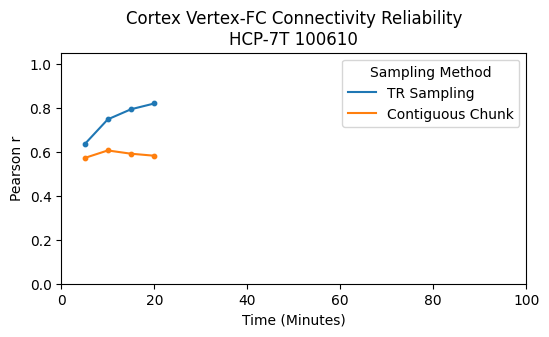

In [68]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hcp_t_s, hcp_rand_r_s, label="TR Sampling")
ax.scatter(hcp_t_s, hcp_rand_r_s, s=10)

ax.plot(hcp_t_s, hcp_chunk_r_s, label="Contiguous Chunk")
ax.scatter(hcp_t_s, hcp_chunk_r_s, s=10)
ax.legend(title="Sampling Method")
ax.set(xlabel="Time (Minutes)", ylabel="Pearson r", title="Cortex Vertex-FC Connectivity Reliability\nHCP-7T 100610")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

(0.0, 100.0)

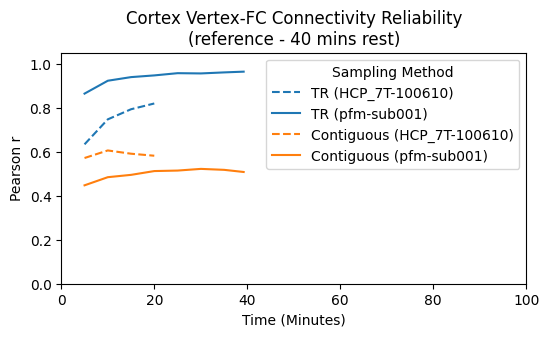

In [82]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hcp_t_s, hcp_rand_r_s, label="TR (HCP_7T-100610)", color="C0", linestyle="--")
ax.plot(t_s, rand_r_s, label="TR (pfm-sub001)", color="C0")


ax.plot(hcp_t_s, hcp_chunk_r_s, label="Contiguous (HCP_7T-100610)", color="C1", linestyle="--")
ax.plot(t_s, chunk_r_s, label="Contiguous (pfm-sub001)", color="C1")

ax.legend(title="Sampling Method")
ax.set(xlabel="Time (Minutes)", ylabel="Pearson r", title="Cortex Vertex-FC Connectivity Reliability\n(reference - 40 mins rest)")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

In [404]:
nr = 1000
a, b = np.random.randn(nr, nr), np.random.randn(nr, nr)



In [408]:
z_s =[0.1, 1, 10, 100]
rtu_s, rf_s = [], []

for z in z_s:
    bz = (a + z * b) / (1 + z)
    a_triu_flat = a[*np.triu_indices_from(a, k=1)]
    b_triu_flat = bz[*np.triu_indices_from(bz, k=1)]
    rtu = np.corrcoef(a_triu_flat, b_triu_flat)[0, 1]
    rf = np.corrcoef(a.ravel(), bz.ravel())[0, 1]
    rtu_s.append(rtu)
    rf_s.append(rf)

rtu_s = np.array(rtu_s)
rf_s = np.array(rf_s)

In [409]:
rtu_s, rf_s

(array([0.9950504 , 0.70855969, 0.10264543, 0.01309619]),
 array([0.99504159, 0.70748279, 0.10021636, 0.01068873]))

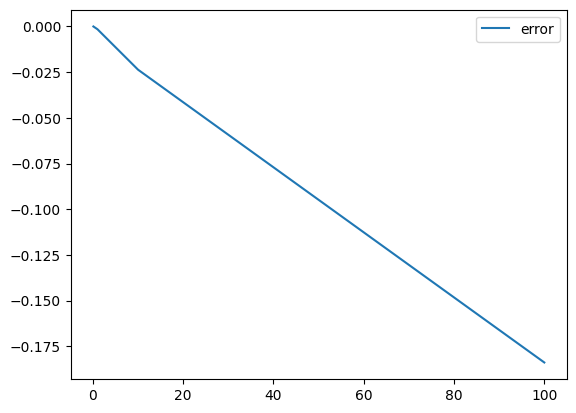

In [410]:
# plt.plot(z_s, rtu_s, label="Triu")
# plt.plot(z_s, rf_s, label="Full")
plt.plot(z_s, (rf_s - rtu_s) / rtu_s, label="error")
plt.legend()

In [311]:
r

np.float64(0.50778)